In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import pickle

In [2]:
loan_data=pd.read_csv('cs-training.csv.zip')

In [3]:
loan_data.shape

(150000, 12)

In [4]:
loan_data.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
loan_data.info

<bound method DataFrame.info of         Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
0                1                 1                              0.766127   
1                2                 0                              0.957151   
2                3                 0                              0.658180   
3                4                 0                              0.233810   
4                5                 0                              0.907239   
...            ...               ...                                   ...   
149995      149996                 0                              0.040674   
149996      149997                 0                              0.299745   
149997      149998                 0                              0.246044   
149998      149999                 0                              0.000000   
149999      150000                 0                              0.850283   

        age  NumberOfTime30-59D

In [6]:
loan_data.describe

<bound method NDFrame.describe of         Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
0                1                 1                              0.766127   
1                2                 0                              0.957151   
2                3                 0                              0.658180   
3                4                 0                              0.233810   
4                5                 0                              0.907239   
...            ...               ...                                   ...   
149995      149996                 0                              0.040674   
149996      149997                 0                              0.299745   
149997      149998                 0                              0.246044   
149998      149999                 0                              0.000000   
149999      150000                 0                              0.850283   

        age  NumberOfTime30-5

In [7]:
loan_data['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [8]:
loan_data.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [9]:
my_imputer = SimpleImputer(strategy='median')
loan_data=pd.DataFrame(my_imputer.fit_transform(loan_data),columns=loan_data.columns)


In [10]:
y = loan_data['SeriousDlqin2yrs']
X = loan_data.drop(columns=['SeriousDlqin2yrs', 'Unnamed: 0'])

In [11]:
X.shape

(150000, 10)

In [12]:
y.shape

(150000,)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
X_train.shape

(105000, 10)

In [15]:
X_test.shape

(45000, 10)

In [16]:
smote = SMOTE(random_state=42)

In [17]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [18]:
pd.Series(y_train_smote).value_counts()

SeriousDlqin2yrs
0.0    97954
1.0    97954
Name: count, dtype: int64

In [19]:
#using RandomForest model
model=RandomForestClassifier(class_weight='balanced',random_state=42)

In [20]:
model.fit(X_train_smote,y_train_smote)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [21]:
y_pred=model.predict(X_test)

In [22]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n         0.0       0.95      0.98      0.96     42020\n         1.0       0.49      0.25      0.33      2980\n\n    accuracy                           0.93     45000\n   macro avg       0.72      0.62      0.65     45000\nweighted avg       0.92      0.93      0.92     45000\n'

In [23]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_threshold = (y_pred_proba >= 0.3).astype(int)

In [24]:
classification_report(y_test, y_pred_threshold)

'              precision    recall  f1-score   support\n\n         0.0       0.96      0.94      0.95     42020\n         1.0       0.36      0.46      0.41      2980\n\n    accuracy                           0.91     45000\n   macro avg       0.66      0.70      0.68     45000\nweighted avg       0.92      0.91      0.92     45000\n'

In [25]:
#using XGBoost model
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb_model.predict(X_test)
classification_report(y_test, y_pred_xgb)

'              precision    recall  f1-score   support\n\n         0.0       0.95      0.99      0.97     42020\n         1.0       0.54      0.21      0.31      2980\n\n    accuracy                           0.94     45000\n   macro avg       0.74      0.60      0.64     45000\nweighted avg       0.92      0.94      0.92     45000\n'

In [26]:
xgb_y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_y_pred_threshold = (xgb_y_pred_proba >= 0.2).astype(int)

In [27]:
classification_report(y_test, xgb_y_pred_threshold)

'              precision    recall  f1-score   support\n\n         0.0       0.97      0.93      0.95     42020\n         1.0       0.36      0.53      0.43      2980\n\n    accuracy                           0.91     45000\n   macro avg       0.66      0.73      0.69     45000\nweighted avg       0.93      0.91      0.92     45000\n'

In [31]:
#Final model XGBoost
pickle.dump(xgb_model, open('loan_default_model.pkl', 'wb'))
feature_names = X.columns.tolist()
pickle.dump(feature_names, open('feature_names.pkl', 'wb'))
pickle.dump(0.2, open('threshold.pkl', 'wb'))
pickle.dump(y, open('target.pkl', 'wb'))
pickle.dump(X, open('X.pkl', 'wb'))

In [29]:
X.columns.tolist()

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

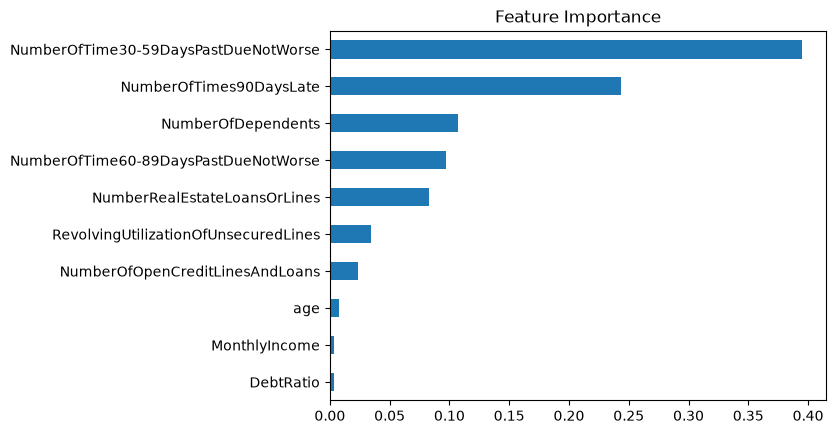

In [30]:
import matplotlib.pyplot as plt

xgb_model.feature_importances_
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()